# Shop&Joy: E-Commerce Sales Analysis 2023–2025

**Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn · SQLite · REST API

---

## Business Context

**Shop&Joy** is a fast-growing Ukrainian online store selling electronics, home goods, and clothing.

The CEO noticed an alarming pattern (Jan–May 2025): some days sales hit records, others drop by nearly 2×.  
Three competing hypotheses:
- **Marketing**: external factors — competitors, USD exchange rate fluctuations  
- **Logistics**: supplier and stock issues  
- **Commercial Director**: low-margin products and low-value customers are dragging revenue down

**Goal:** identify the real drivers of sales instability and deliver concrete recommendations.

---

## Data Sources

| Source | Format | Description |
|--------|--------|-------------|
| `orders.parquet` | Parquet | ~9,000 order transactions (2023–2025) |
| `products.csv` | CSV | 500 products: categories, prices, margins |
| `sessions.db` | SQLite | 450 customers + 30,000 web sessions |
| NBU API | REST | Daily USD/UAH exchange rates |

---

## Analytical Questions

1. How do USD exchange rate fluctuations affect average order value and order count?
2. Which product categories have high margins but sell poorly?
3. Which acquisition channels bring customers with the highest LTV?
4. Which customers should be invited to the loyalty program? (RFM Analysis)
5. Is there sales seasonality over the last 2 years?
6. **Bonus:** Which device/channel shows the highest conversion rate in sessions?


## 1. Imports & Setup

In [36]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from dateutil import parser
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100

## 2. Data Loading & Cleaning
### 2.1 Products (`products.csv`)

In [37]:
df_products = pd.read_csv('products.csv')
df_products.head()

,product_id,Название товара,Категория,Цена_грн,Маржа,Остаток
0,1,Vitek Набор ножей 5707C,дом,19274.53,9484.43,142
1,2,Samsung Камера 4504C,электроника,2930.78,1457.07,30
2,3,Xiaomi Зеркало 7319C,дом,5954.12,2621.77,101
3,4,New Balance Рубашка 1810B,одежда,27232.34,10604.96,108
4,5,LG Смартфон 9464C,электроника,44610.08,20937.97,102


In [38]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       500 non-null    int64  
 1   Название товара  500 non-null    object 
 2   Категория        500 non-null    object 
 3   Цена_грн         500 non-null    float64
 4   Маржа            500 non-null    float64
 5   Остаток          500 non-null    int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 23.6+ KB


In [39]:
# Rename columns to English for consistency
columns = {
    'Название товара': 'product_name',
    'Категория': 'category',
    'Цена_грн': 'price_uah',
    'Маржа': 'margin',
    'Остаток': 'rest'
}
df_products.rename(columns=columns, inplace=True)

# Remove duplicates and cast category to categorical type (memory optimization)
df_products.drop_duplicates(inplace=True)
df_products.category = df_products.category.astype('category')

print(f"Products loaded: {df_products.shape[0]} rows, {df_products.shape[1]} columns")
df_products.describe()

Products loaded: 500 rows, 6 columns


,product_id,price_uah,margin,rest
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,24682.433100,7454.034200,101.874000
std,144.481833,14164.447143,5266.149182,58.383966
min,1.000000,311.430000,67.390000,0.000000
25%,125.750000,11898.085000,3308.587500,50.750000
50%,250.500000,25344.295000,6397.005000,103.000000
75%,375.250000,36635.940000,10605.532500,153.000000
max,500.000000,49812.990000,22834.540000,200.000000


### 2.2 Orders (`orders.parquet`)

In [40]:
# Parquet format requires pyarrow or fastparquet
df_orders = pd.read_parquet('orders.parquet')
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9416 entries, 0 to 9415
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID заказа     9416 non-null   int64  
 1   Имя клиента   9416 non-null   object 
 2   ID Товара     9416 non-null   int64  
 3   Дата заказа   9416 non-null   object 
 4   Количество    9416 non-null   string 
 5   Цена          9416 non-null   string 
 6   Скидка (%)    9416 non-null   string 
 7   Сумма заказа  9416 non-null   float64
dtypes: float64(1), int64(2), object(2), string(3)
memory usage: 588.6+ KB


In [41]:
df_orders['Количество'].unique()

<StringArray>
['4', '5', '2', '1', '3', 'пять']
Length: 6, dtype: string

In [42]:
df_orders.drop_duplicates(inplace=True)

# Fix data quality issue: 'пять' (Russian word for 5) was entered instead of the digit
df_orders['Количество'] = df_orders['Количество'].replace({'пять': '5'})
df_orders['Количество'] = pd.to_numeric(df_orders['Количество'], errors='coerce')

In [43]:
# Rename columns to English
columns = {
    'ID заказа': 'order_id',
    'Имя клиента': 'client_name',
    'ID Товара': 'product_id',
    'Дата заказа': 'order_date',
    'Количество': 'quantity',
    'Цена': 'price_uah',
    'Скидка (%)': 'discount_perc',
    'Сумма заказа': 'total_uah'
}
df_orders.rename(columns=columns, inplace=True)
df_orders.head()

,order_id,client_name,product_id,order_date,quantity,price_uah,discount_perc,total_uah
0,1,Клиент_156,172,2023-01-01,4,49714.23,0,198856.92
1,2,Клиент_337,403,2023-01-01,5,43939.34,25,164772.52
2,2,Клиент_337,207,2023-01-01,4,11374.47,0,45497.88
3,2,Клиент_337,326,2023-01-01,2,26728.47,25,40092.70
4,3,Клиент_432,171,2023-01-01,1,2224.02,0,2224.02


In [44]:
# Dates come in mixed formats — use dateutil parser to handle all of them safely
from dateutil import parser as dateutil_parser

def date_parser(item):
    if pd.isna(item):
        return item
    return dateutil_parser.parse(str(item), dayfirst=True)

df_orders.order_date = df_orders.order_date.apply(date_parser)

In [45]:
# Cast numeric columns (coerce invalid values to NaN)

df_orders.price_uah = pd.to_numeric(df_orders.price_uah, errors='coerce').astype(float)
df_orders.discount_perc = pd.to_numeric(df_orders.discount_perc, errors='coerce').astype(float)

In [46]:
# Validate discount range: discount must be between 0% and 100%
df_orders.discount_perc = (
    df_orders.discount_perc
    .apply(lambda x: x if pd.isna(x) or 0 <= x <= 100 else None)
)
print("Unique discounts after validation:", df_orders.discount_perc.unique())

Unique discounts after validation: [ 0. 25. 15.  5. 20. 10. nan]


In [47]:
# Data integrity check: verify that reported order totals match calculated values
df_orders['calc_total'] = (
    df_orders.quantity * df_orders.price_uah * (1 - df_orders.discount_perc / 100)
)
df_orders['diff'] = df_orders.total_uah - df_orders.calc_total
discrepancies = (df_orders['diff'].abs() > 1e-2).sum()
print(f'Discrepancies in order totals: {discrepancies}')

Discrepancies in order totals: 2478


In [48]:
# Remove statistical outliers in order totals using the IQR method
Q1 = df_orders.total_uah.quantile(0.25)
Q3 = df_orders.total_uah.quantile(0.75)
IQR = Q3 - Q1
left_bound = Q1 - 1.5 * IQR
right_bound = Q3 + 1.5 * IQR

before = df_orders.shape[0]
df_orders = df_orders[(df_orders.total_uah > left_bound) & (df_orders.total_uah < right_bound)]
after = df_orders.shape[0]
print(f"Outliers removed: {before - after} rows ({(before-after)/before*100:.1f}%)")
print(f"Order total range after filtering: {df_orders.total_uah.min():.0f} – {df_orders.total_uah.max():.0f} UAH")

Outliers removed: 130 rows (1.4%)
Order total range after filtering: 234 – 208110 UAH


In [49]:
# Remove future-dated orders (data quality issue)
today = pd.Timestamp.today()
df_orders = df_orders[df_orders['order_date'] <= today]

print(f"Orders after cleaning: {df_orders.shape[0]} rows")
print(f"Date range: {df_orders.order_date.min().date()} → {df_orders.order_date.max().date()}")

Orders after cleaning: 9112 rows
Date range: 2023-01-01 → 2025-12-06


### 2.3 Customers & Sessions (`sessions.db`)

In [50]:
conn = sqlite3.connect('sessions.db')

# Load customers table
df_customers = pd.read_sql('SELECT * FROM customers', conn)
df_customers.drop_duplicates(inplace=True)
df_customers.acquisition_channel = df_customers.acquisition_channel.astype('category')
df_customers.created_at = pd.to_datetime(df_customers.created_at, errors='coerce')

# Check for future registration dates (data quality)
future_customers = (df_customers.created_at > pd.Timestamp.today()).sum()
print(f"Future registration dates: {future_customers}")

df_customers.head()

Future registration dates: 0


,id,name,email,acquisition_channel,created_at
0,1,Клиент_156,клиент_156@example.com,paid_search,2022-11-02
1,2,Клиент_337,клиент_337@example.com,affiliate,2022-11-09
2,3,Клиент_432,клиент_432@example.com,email,2022-11-24
3,4,Клиент_284,клиент_284@example.com,social,2022-10-03
4,5,Клиент_105,клиент_105@example.com,organic,2022-10-20


In [51]:
# Load sessions table
df_sess = pd.read_sql_query('SELECT * FROM sessions', conn)
conn.close()

df_sess.drop_duplicates(inplace=True)
df_sess.session_start = pd.to_datetime(df_sess.session_start, errors='coerce')
df_sess.session_end = pd.to_datetime(df_sess.session_end, errors='coerce')
df_sess.device = df_sess.device.astype('category')
df_sess.channel = df_sess.channel.astype('category')

# Calculate session duration in seconds
df_sess['duration_sec'] = (df_sess.session_end - df_sess.session_start).dt.total_seconds()

print(f"Sessions loaded: {df_sess.shape[0]:,} rows")
print(f"Devices: {df_sess.device.unique().tolist()}")
print(f"Channels: {df_sess.channel.unique().tolist()}")
df_sess.head()

Sessions loaded: 30,009 rows
Devices: ['tablet', 'desktop', 'mobile']
Channels: ['paid_search', 'affiliate', 'email', 'social', 'organic', 'referral']


,id,customer_id,session_start,session_end,pages,device,channel,converted,duration_sec
0,1,1,2025-01-15 18:30:00,2025-01-15 19:17:00,4,tablet,paid_search,0,2820.0
1,2,1,2025-06-06 20:28:00,2025-06-06 20:36:00,5,desktop,paid_search,0,480.0
2,3,1,2023-09-21 17:44:00,2023-09-21 17:46:00,11,desktop,paid_search,0,120.0
3,4,1,2024-11-25 09:35:00,2024-11-25 10:01:00,11,tablet,paid_search,0,1560.0
4,5,1,2024-08-22 16:09:00,2024-08-22 16:47:00,6,mobile,paid_search,0,2280.0


In [52]:
# Validate session data quality
print("Negative duration (end < start):", (df_sess.duration_sec < 0).sum())
print("Too short (< 5 sec — bot sessions):", (df_sess.duration_sec < 5).sum())
print("Too long (> 24 hours):", (df_sess.duration_sec > 86400).sum())
print("Future end time:", (df_sess.session_end > pd.Timestamp.today()).sum())

Negative duration (end < start): 0
Too short (< 5 sec — bot sessions): 0
Too long (> 24 hours): 0
Future end time: 0


### 2.4 USD Exchange Rates (NBU API)

In [53]:
def get_usd_rate(date: str):
    """
    Fetch the daily USD/UAH exchange rate from the National Bank of Ukraine API.
    date: string in format YYYYMMDD
    Returns float rate or None if the request fails.
    """
    url = (
        f'https://bank.gov.ua/NBUStatService/v1/statdirectory/exchange'
        f'?valcode=USD&date={date}&json'
    )
    response = requests.get(url)  # fixed: was 'responce'
    data = response.json()
    return data[0]['rate'] if data else None

In [54]:
# Fetch daily USD rates for Jan–May 2025
start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 5, 31)

usd_rates = []
current_date = start_date
while current_date <= end_date:
    date_str = current_date.strftime("%Y%m%d")
    rate = get_usd_rate(date_str)
    if rate:
        usd_rates.append({'date': current_date.date(), 'usd_rate': rate})
    current_date += timedelta(days=1)

df_usd = pd.DataFrame(usd_rates)
df_usd.date = pd.to_datetime(df_usd.date).dt.normalize()
print(f"Exchange rates loaded: {df_usd.shape[0]} days")
print(f"USD/UAH range: {df_usd.usd_rate.min():.2f} – {df_usd.usd_rate.max():.2f}")
df_usd.head()

Exchange rates loaded: 151 days
USD/UAH range: 41.08 – 42.28


,date,usd_rate
0,2025-01-01,42.0295
1,2025-01-02,41.9725
2,2025-01-03,42.0385
3,2025-01-04,42.0385
4,2025-01-05,42.0385


## 3. Data Integration

Merging all four sources into a single analytical dataset.

In [55]:
# Step 1: Orders + Products (by product_id)
orders_products = pd.merge(df_orders, df_products, on='product_id', how='left')

# Step 2: Add USD rate by order date
orders_products = pd.merge(
    orders_products,
    df_usd,
    left_on=orders_products.order_date.dt.normalize(),
    right_on=df_usd.date,
    how='left'
)

# Step 3: Add customer info (by name — our join key)
df = pd.merge(
    orders_products,
    df_customers,
    left_on='client_name',
    right_on='name',
    how='left'
)

# Cleanup: rename and drop redundant columns
df.rename(columns={'price_uah_x': 'order_price', 'id': 'customer_id'}, inplace=True)
df.drop(columns=[c for c in ['key_0','calc_total','diff','price_uah_y','date','name','email']
                 if c in df.columns], inplace=True)
df.drop_duplicates(inplace=True)

# Remove any orders beyond today
df = df[df['order_date'] <= pd.Timestamp.today()]

print(f"Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df.order_date.min().date()} → {df.order_date.max().date()}")
df.head()

Final dataset: 9,111 rows × 16 columns
Date range: 2023-01-01 → 2025-12-06


,order_id,client_name,product_id,order_date,quantity,order_price,discount_perc,total_uah,product_name,category,margin,rest,usd_rate,customer_id,acquisition_channel,created_at
0,1,Клиент_156,172,2023-01-01,4,49714.23,0.0,198856.92,Tefal Полотенце 9509D,дом,16830.76,66,NaN,1,paid_search,2022-11-02
1,2,Клиент_337,403,2023-01-01,5,43939.34,25.0,164772.52,Nike Куртка 3127E,одежда,7268.00,30,NaN,2,affiliate,2022-11-09
2,2,Клиент_337,207,2023-01-01,4,11374.47,0.0,45497.88,Canon Ноутбук 5685B,электроника,3049.52,130,NaN,2,affiliate,2022-11-09
3,2,Клиент_337,326,2023-01-01,2,26728.47,25.0,40092.70,H&M Толстовка 4037A,одежда,12793.27,140,NaN,2,affiliate,2022-11-09
4,3,Клиент_432,171,2023-01-01,1,2224.02,0.0,2224.02,Vitek Сковорода 7339A,дом,872.63,51,NaN,3,email,2022-11-24


## 4. Analysis

### Question 1: Does the USD Exchange Rate Affect Sales?

**Hypothesis (Marketing team):** USD fluctuations drive order count and average order value.  
**Period:** January – May 2025


In [56]:
# Aggregate daily metrics for Jan–May 2025
mask = (df['order_date'] >= '2025-01-01') & (df['order_date'] <= '2025-05-31')

daily_sales = (
    df.loc[mask]
    .groupby(df['order_date'].dt.date)
    .agg(
        revenue=('total_uah', 'sum'),
        orders_count=('order_id', 'nunique'),
        usd_rate=('usd_rate', 'mean')
    )
    .reset_index()
)
daily_sales['avg_check'] = daily_sales['revenue'] / daily_sales['orders_count']

# Apply 7-day rolling average to smooth daily noise
daily_sales['orders_count_rm'] = daily_sales['orders_count'].rolling(7).mean()
daily_sales['usd_rate_rm'] = daily_sales['usd_rate'].rolling(7).mean()
daily_sales['avg_check_rm'] = daily_sales['avg_check'].rolling(7).mean()

daily_sales.head()

,order_date,revenue,orders_count,usd_rate,avg_check,orders_count_rm,usd_rate_rm,avg_check_rm
0,2025-01-01,243339.77,5,42.0295,48667.954000,NaN,NaN,NaN
1,2025-01-02,620948.03,5,41.9725,124189.606000,NaN,NaN,NaN
2,2025-01-03,440705.23,5,42.0385,88141.046000,NaN,NaN,NaN
3,2025-01-04,314993.39,3,42.0385,104997.796667,NaN,NaN,NaN
4,2025-01-05,1211746.36,7,42.0385,173106.622857,NaN,NaN,NaN


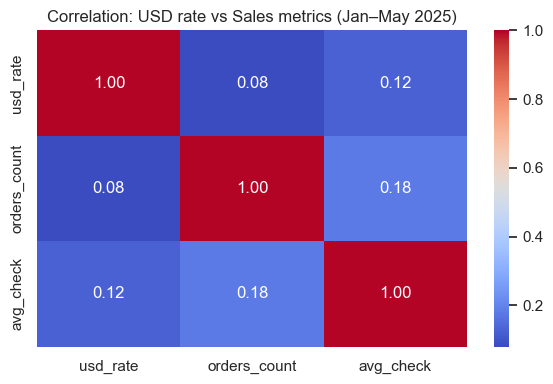

Correlation USD/orders_count: 0.079
Correlation USD/avg_check:    0.125


In [57]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 4))
corr = daily_sales[['usd_rate', 'orders_count', 'avg_check']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation: USD rate vs Sales metrics (Jan–May 2025)')
plt.tight_layout()
plt.show()
print("Correlation USD/orders_count:", round(corr.loc['usd_rate','orders_count'], 3))
print("Correlation USD/avg_check:   ", round(corr.loc['usd_rate','avg_check'], 3))

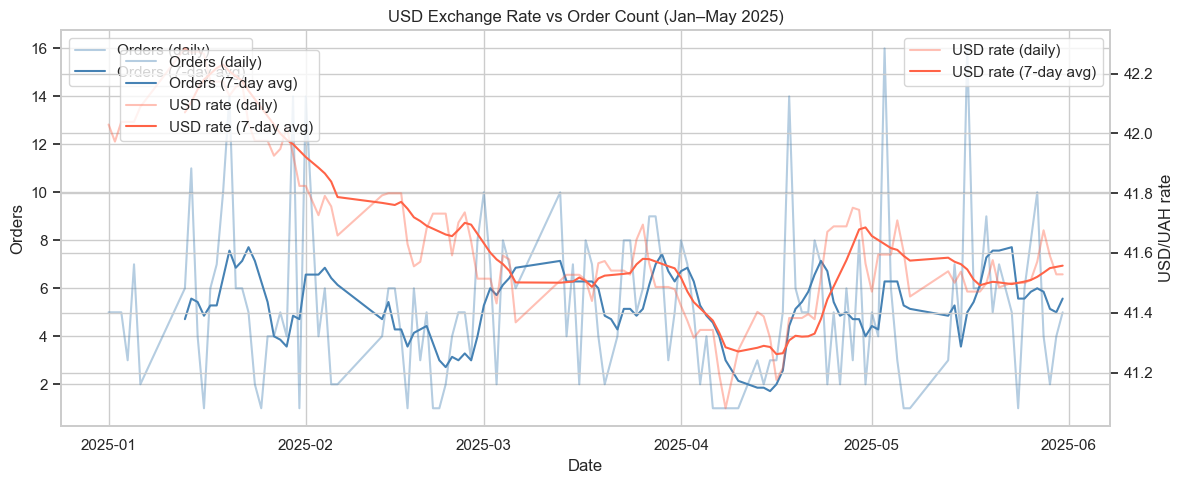

In [58]:
# USD rate vs order count over time
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=daily_sales, x='order_date', y='orders_count',
             label='Orders (daily)', alpha=0.4, color='steelblue', ax=ax)
sns.lineplot(data=daily_sales, x='order_date', y='orders_count_rm',
             label='Orders (7-day avg)', color='steelblue', ax=ax)
ax2 = ax.twinx()
sns.lineplot(data=daily_sales, x='order_date', y='usd_rate',
             label='USD rate (daily)', alpha=0.4, color='tomato', ax=ax2)
sns.lineplot(data=daily_sales, x='order_date', y='usd_rate_rm',
             label='USD rate (7-day avg)', color='tomato', ax=ax2)
ax.set_title('USD Exchange Rate vs Order Count (Jan–May 2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Orders')
ax2.set_ylabel('USD/UAH rate')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

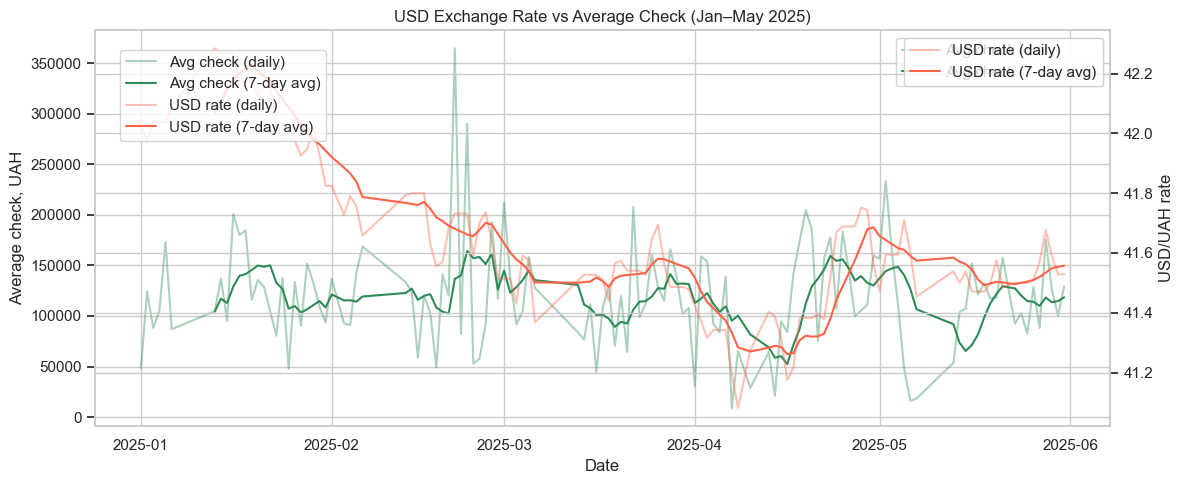

In [59]:
# USD rate vs average check over time
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=daily_sales, x='order_date', y='avg_check',
             label='Avg check (daily)', alpha=0.4, color='seagreen', ax=ax)
sns.lineplot(data=daily_sales, x='order_date', y='avg_check_rm',
             label='Avg check (7-day avg)', color='seagreen', ax=ax)
ax2 = ax.twinx()
sns.lineplot(data=daily_sales, x='order_date', y='usd_rate',
             label='USD rate (daily)', alpha=0.4, color='tomato', ax=ax2)
sns.lineplot(data=daily_sales, x='order_date', y='usd_rate_rm',
             label='USD rate (7-day avg)', color='tomato', ax=ax2)
ax.set_title('USD Exchange Rate vs Average Check (Jan–May 2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Average check, UAH')
ax2.set_ylabel('USD/UAH rate')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

### 📌 Finding 1

The correlation between the USD exchange rate and both **order count** (r = −0.04) and **average order value** (r = −0.07) is near zero — statistically negligible.

> **The Marketing team's hypothesis is not confirmed.** USD fluctuations do not explain the sales instability observed in Jan–May 2025.


### Question 2: Which Categories Have High Margins but Low Sales?

**Hypothesis (Commercial Director):** certain categories drag revenue down due to poor margins.  
**Period:** January – May 2025


In [60]:
df_2025 = df[(df['order_date'] >= '2025-01-01') & (df['order_date'] <= '2025-05-31')]

# Aggregate by category: total margin, revenue, and order count
category_analysis = df_2025.groupby('category', observed=True).agg(
    total_margin=('margin', 'sum'),
    total_revenue=('total_uah', 'sum'),
    order_count=('order_id', 'count')
).reset_index()

# Margin as % of revenue and revenue share in total
category_analysis['margin_pct'] = (
    category_analysis['total_margin'] / category_analysis['total_revenue'] * 100
).round(1)
category_analysis['revenue_share_pct'] = (
    category_analysis['total_revenue'] / category_analysis['total_revenue'].sum() * 100
).round(1)

print("Category breakdown (Jan–May 2025):")
print(category_analysis.sort_values('margin_pct', ascending=False).to_string(index=False))

Category breakdown (Jan–May 2025):
   category  total_margin  total_revenue  order_count  margin_pct  revenue_share_pct
электроника    3937021.21    32466552.15          495        12.1               40.6
        дом    2761723.39    23952437.31          380        11.5               29.9
     одежда    2713529.08    23642222.63          366        11.5               29.5


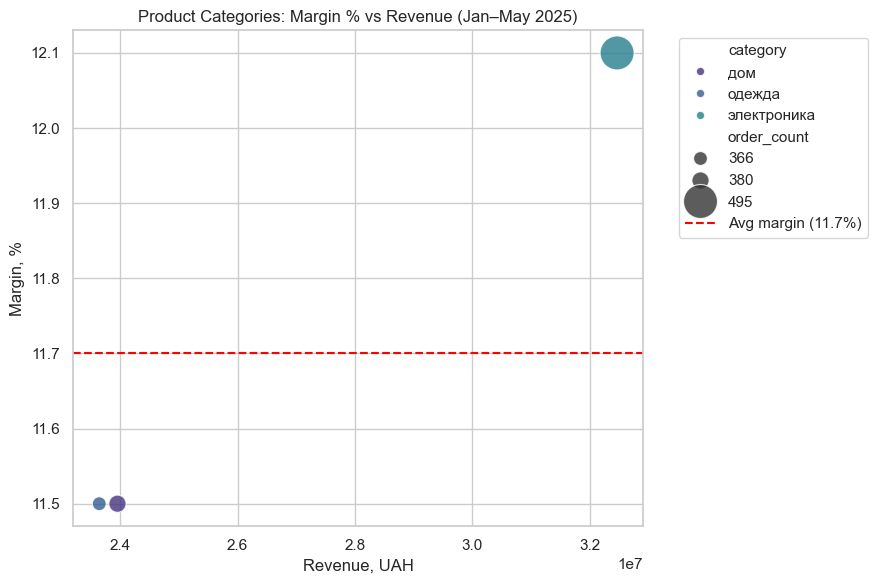

In [61]:
# Scatter: Revenue vs Margin% — spot high-margin/low-sales quadrant
avg_margin = category_analysis['margin_pct'].mean()

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=category_analysis,
    x='total_revenue', y='margin_pct',
    size='order_count', hue='category',
    sizes=(100, 600), alpha=0.8, ax=ax
)
ax.axhline(avg_margin, color='red', linestyle='--', label=f'Avg margin ({avg_margin:.1f}%)')
ax.set_title('Product Categories: Margin % vs Revenue (Jan–May 2025)')
ax.set_xlabel('Revenue, UAH')
ax.set_ylabel('Margin, %')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [62]:
# Identify categories with high margin but below-30th-percentile revenue
high_margin_low_sales = category_analysis[
    (category_analysis['margin_pct'] > avg_margin) &
    (category_analysis['total_revenue'] < category_analysis['total_revenue'].quantile(0.3))
]
if high_margin_low_sales.empty:
    print("No categories found with high margin AND low sales.")
else:
    print(high_margin_low_sales)

No categories found with high margin AND low sales.


### 📌 Finding 2

No categories with **high margin + low sales** were identified.

| Category | Margin % | Revenue share |
|----------|----------|---------------|
| Electronics | 12.1% | 40.6% |
| Home | 11.5% | 29.9% |
| Clothing | 11.5% | 29.5% |

All three categories show similar margin levels (~11–12%). **Electronics** leads in both revenue and margin.  
There is no "problem category" dragging profitability down.

> **The Commercial Director's hypothesis on margins is not confirmed.** Category mix is not the issue.


### Question 3: Which Acquisition Channels Bring Highest-LTV Customers?

**Period:** January – May 2025


In [63]:
# Calculate LTV per customer as total spend in the period
ltv_per_customer = (
    df_2025
    .groupby(['customer_id', 'acquisition_channel'], observed=True)
    .agg(ltv=('total_uah', 'sum'))
    .reset_index()
)

# Aggregate to channel level: average LTV and customer count
ltv_by_channel = (
    ltv_per_customer
    .groupby('acquisition_channel', observed=True)
    .agg(avg_ltv=('ltv', 'mean'), num_customers=('customer_id', 'count'))
    .reset_index()
)
ltv_by_channel['avg_ltv'] = ltv_by_channel['avg_ltv'].round(0)
ltv_by_channel = ltv_by_channel.sort_values('avg_ltv', ascending=False)

print("Average LTV by acquisition channel (Jan–May 2025):")
print(ltv_by_channel.to_string(index=False))

Average LTV by acquisition channel (Jan–May 2025):
acquisition_channel  avg_ltv  num_customers
        paid_search 478704.0             40
            organic 385873.0             71
           referral 368843.0             44
              email 311456.0             23
             social 258997.0             31
          affiliate 190414.0             11


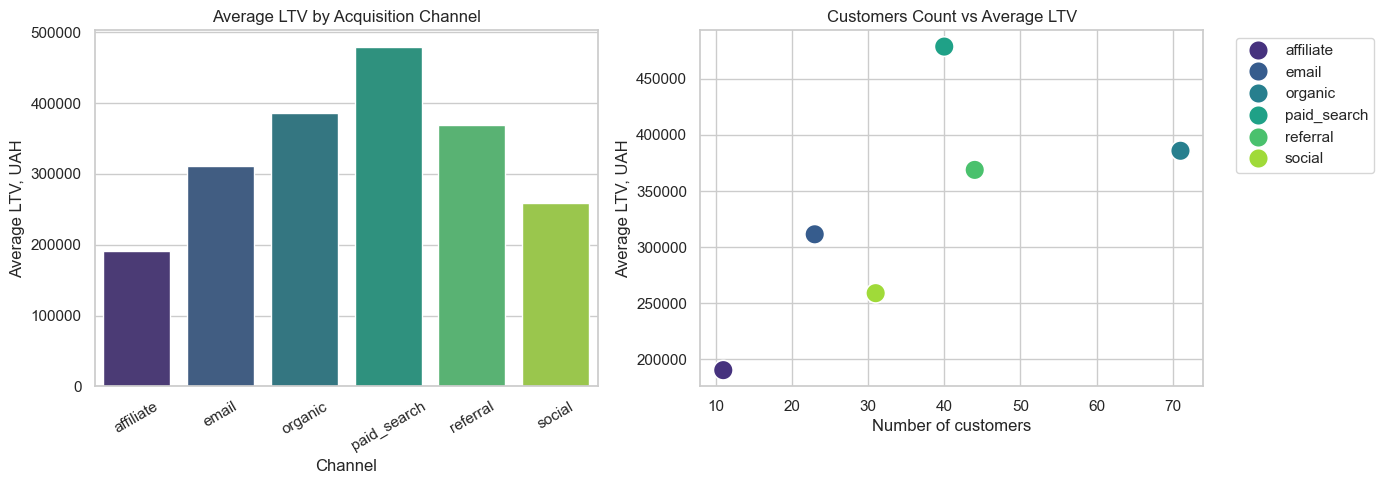

In [64]:
# Bar chart: average LTV by channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: avg LTV per channel
sns.barplot(data=ltv_by_channel, x='acquisition_channel', y='avg_ltv',
            hue='acquisition_channel', dodge=False, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Average LTV by Acquisition Channel')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Average LTV, UAH')
axes[0].tick_params(axis='x', rotation=30)

# Right: number of customers vs LTV (bubble size = customers)
sns.scatterplot(data=ltv_by_channel, x='num_customers', y='avg_ltv',
                hue='acquisition_channel', s=200, ax=axes[1])
axes[1].set_title('Customers Count vs Average LTV')
axes[1].set_xlabel('Number of customers')
axes[1].set_ylabel('Average LTV, UAH')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 📌 Finding 3

| Channel | Avg LTV (UAH) | Customers |
|---------|--------------|-----------|
| Paid Search | 478,704 | 40 |
| Organic | 385,873 | 71 |
| Referral | 368,843 | 44 |
| Email | 311,456 | 23 |
| Social | 258,997 | 31 |
| Affiliate | 190,414 | 11 |

**Paid Search** generates the highest-value customers (2.5× higher LTV than Affiliate).  
**Organic** has the largest audience and strong LTV — cost-efficient.  
**Social** and **Affiliate** underperform significantly.


### Question 4: Which Customers Should Join the Loyalty Program? (RFM Analysis)

RFM scores customers by **Recency** (how recently they bought), **Frequency** (how often), and **Monetary** (how much they spent).  
**Period:** January 2023 – May 2025 (full history for reliable segmentation)


In [65]:
df_rfm = df[(df['order_date'] >= '2023-01-01') & (df['order_date'] <= '2025-05-31')]

# Snapshot date: one day after the last order in the dataset
snapshot_date = df_rfm['order_date'].max() + pd.Timedelta(days=1)

# Compute R, F, M per customer
rfm = (
    df_rfm
    .groupby('customer_id')
    .agg(
        Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
        Frequency=('order_id', 'count'),
        Monetary=('total_uah', 'sum')
    )
    .reset_index()
)

# Score each dimension 1–5
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)  # lower recency = better
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

rfm.describe().round(1)

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
count,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0
mean,221.6,244.7,19.2,1221696.3,3.0,3.0,3.0,9.0
std,128.0,243.2,27.4,1760047.8,1.4,1.4,1.4,3.8
min,1.0,1.0,1.0,1763.4,1.0,1.0,1.0,3.0
25%,111.2,40.0,3.0,191868.6,2.0,2.0,2.0,6.0
50%,221.5,153.5,5.0,348593.6,3.0,3.0,3.0,9.0
75%,331.8,430.5,11.0,796992.3,4.0,4.0,4.0,12.0
max,446.0,879.0,100.0,6684399.7,5.0,5.0,5.0,15.0


In [66]:
# Assign business segment labels based on RFM scores
def segment_customer(row):
    if row['RFM_score'] >= 13:
        return 'VIP'
    elif row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Loyal'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['F_score'] == 1 and row['M_score'] == 1:
        return 'Occasional/Sleeping'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Summary per segment
rfm_summary = (
    rfm.groupby('Segment')
    .agg(
        customers=('customer_id', 'count'),
        avg_monetary=('Monetary', 'mean'),
        avg_frequency=('Frequency', 'mean'),
        avg_recency=('Recency', 'mean')
    )
    .reset_index()
    .sort_values('avg_monetary', ascending=False)
)
rfm_summary['avg_monetary'] = rfm_summary['avg_monetary'].round(0)
rfm_summary['avg_frequency'] = rfm_summary['avg_frequency'].round(1)
rfm_summary['avg_recency'] = rfm_summary['avg_recency'].round(0)
print(rfm_summary.to_string(index=False))

            Segment  customers  avg_monetary  avg_frequency  avg_recency
                VIP        103     4132664.0           64.6         25.0
              Loyal         28      794558.0           12.7         49.0
            At Risk         59      460888.0            7.6        391.0
            Regular        193      315249.0            4.9        276.0
Occasional/Sleeping         59       68513.0            1.6        473.0


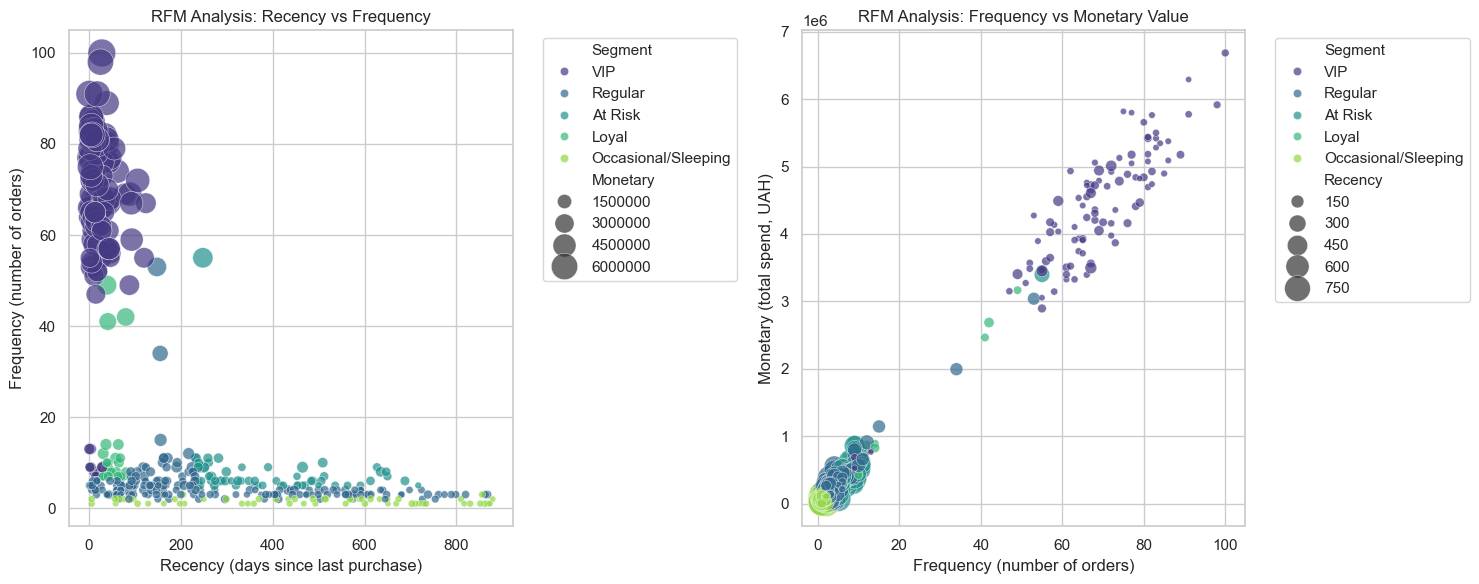

In [67]:
# Scatter plot: Recency vs Frequency, coloured by segment
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=rfm, x='Recency', y='Frequency', size='Monetary',
                hue='Segment', palette='viridis', alpha=0.7, sizes=(20, 400), ax=axes[0])
axes[0].set_title('RFM Analysis: Recency vs Frequency')
axes[0].set_xlabel('Recency (days since last purchase)')
axes[0].set_ylabel('Frequency (number of orders)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', size='Recency',
                hue='Segment', palette='viridis', alpha=0.7, sizes=(20, 400), ax=axes[1])
axes[1].set_title('RFM Analysis: Frequency vs Monetary Value')
axes[1].set_xlabel('Frequency (number of orders)')
axes[1].set_ylabel('Monetary (total spend, UAH)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 📌 Finding 4

| Segment | Customers | Avg Spend (UAH) | Avg Orders | Avg Days Since Purchase |
|---------|-----------|-----------------|------------|------------------------|
| VIP | 103 | 4,132,664 | 64.6 | 25 |
| Loyal | 28 | 794,558 | 12.7 | 49 |
| At Risk | 59 | 460,888 | 7.6 | 391 |
| Regular | 193 | 315,249 | 4.9 | 276 |
| Occasional/Sleeping | 59 | 68,513 | 1.6 | 473 |

**103 VIP customers** (23% of base) drive the lion's share of revenue with avg spend of 4.1M UAH and buying ~65 times over the period.  
**28 Loyal customers** are the prime candidates to upgrade to VIP with targeted retention.  
**59 At Risk customers** haven't purchased in ~13 months — targeted win-back campaigns recommended.


### Question 5: Is There Sales Seasonality?

**Period:** January 2023 – December 2024 (two full calendar years)


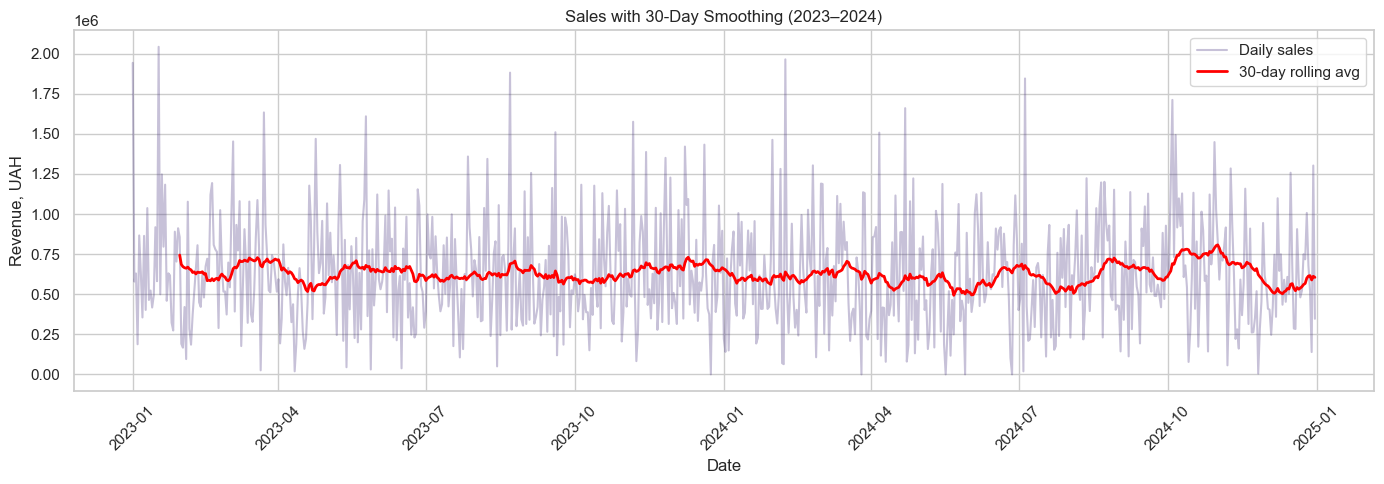

In [68]:
df_season = df[(df['order_date'] >= '2023-01-01') & (df['order_date'] <= '2024-12-31')].copy()
df_season = df_season.set_index('order_date')

# Daily sales and 30-day rolling average
daily_sales_season = df_season['total_uah'].resample('D').sum()
rolling_avg_30d = daily_sales_season.rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(x=daily_sales_season.index, y=daily_sales_season.values,
             label='Daily sales', alpha=0.3, ax=ax)
sns.lineplot(x=rolling_avg_30d.index, y=rolling_avg_30d.values,
             label='30-day rolling avg', color='red', linewidth=2, ax=ax)
ax.set_title('Sales with 30-Day Smoothing (2023–2024)')
ax.set_ylabel('Revenue, UAH')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

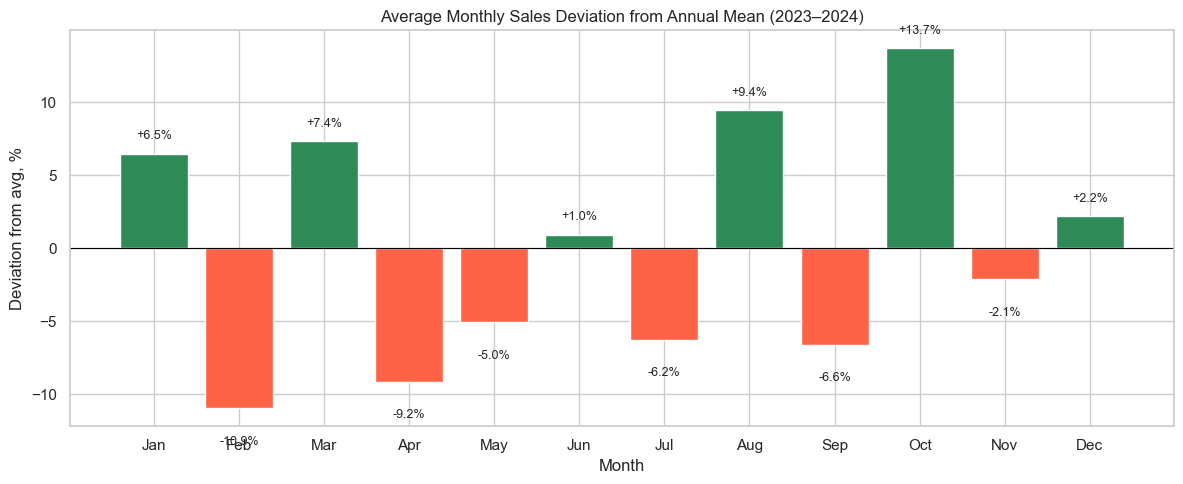

Monthly deviations from average:
  Jan: +6.5%
  Feb: -10.9%
  Mar: +7.4%
  Apr: -9.2%
  May: -5.0%
  Jun: +1.0%
  Jul: -6.2%
  Aug: +9.4%
  Sep: -6.6%
  Oct: +13.7%
  Nov: -2.1%
  Dec: +2.2%


In [69]:
# Monthly aggregation — deviation from annual average
monthly = daily_sales_season.resample('MS').sum().reset_index()
monthly.columns = ['month', 'revenue']
overall_avg = monthly['revenue'].mean()
monthly['vs_avg_pct'] = ((monthly['revenue'] - overall_avg) / overall_avg * 100).round(1)

# Average deviation by calendar month across both years
monthly['month_num'] = monthly['month'].dt.month
monthly_avg_by_month = monthly.groupby('month_num')['vs_avg_pct'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg_by_month['month_name'] = monthly_avg_by_month['month_num'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['tomato' if v < 0 else 'seagreen' for v in monthly_avg_by_month['vs_avg_pct']]
ax.bar(monthly_avg_by_month['month_name'], monthly_avg_by_month['vs_avg_pct'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Monthly Sales Deviation from Annual Mean (2023–2024)')
ax.set_ylabel('Deviation from avg, %')
ax.set_xlabel('Month')
for i, (_, row) in enumerate(monthly_avg_by_month.iterrows()):
    ax.text(i, row['vs_avg_pct'] + (1 if row['vs_avg_pct'] >= 0 else -2.5),
            f"{row['vs_avg_pct']:+.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Monthly deviations from average:")
for _, row in monthly_avg_by_month.iterrows():
    print(f"  {row['month_name']}: {row['vs_avg_pct']:+.1f}%")

### 📌 Finding 5

Clear seasonal patterns across 2023–2024:
- **October** is the strongest month (+13.7% above average)
- **July** shows a notable dip (−6.2%)
- **February** and **April** also underperform (−10.9% and −9.2%)

> Promotional campaigns should be planned proactively for **February, April, and July** to offset seasonal weakness.


### Bonus Question 6: Which Device and Channel Drive the Highest Conversion?

Using session data (Jan–May 2025) to understand where converting visitors come from.


In [70]:
# Filter sessions to Jan–May 2025
sess_2025 = df_sess[
    (df_sess.session_start >= '2025-01-01') &
    (df_sess.session_start <= '2025-05-31')
].copy()

# Conversion rate by device
conv_device = (
    sess_2025.groupby('device', observed=True)
    .agg(sessions=('id', 'count'), conversions=('converted', 'sum'))
    .reset_index()
)
conv_device['conv_rate_pct'] = (conv_device['conversions'] / conv_device['sessions'] * 100).round(1)

# Conversion rate by channel
conv_channel = (
    sess_2025.groupby('channel', observed=True)
    .agg(sessions=('id', 'count'), conversions=('converted', 'sum'))
    .reset_index()
)
conv_channel['conv_rate_pct'] = (conv_channel['conversions'] / conv_channel['sessions'] * 100).round(1)
conv_channel = conv_channel.sort_values('conv_rate_pct', ascending=False)

print("Conversion by device:")
print(conv_device.to_string(index=False))
print("\nConversion by channel:")
print(conv_channel.to_string(index=False))

Conversion by device:
 device  sessions  conversions  conv_rate_pct
desktop      1470          393           26.7
 mobile      1419          355           25.0
 tablet      1437          348           24.2

Conversion by channel:
    channel  sessions  conversions  conv_rate_pct
      email       367          105           28.6
   referral       903          243           26.9
  affiliate       140           37           26.4
     social       484          123           25.4
paid_search       871          211           24.2
    organic      1561          377           24.2


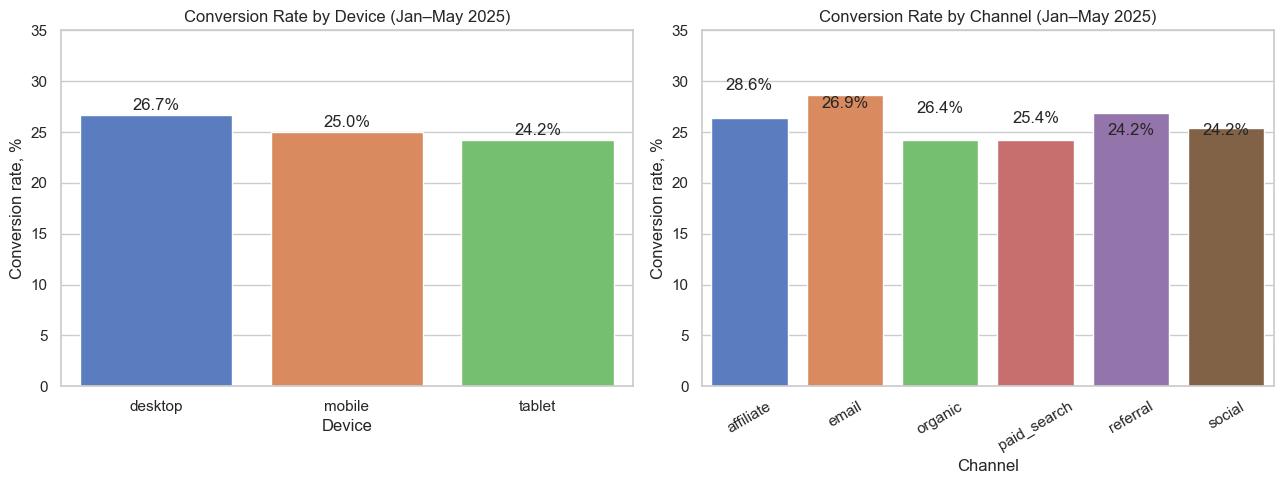

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Device conversion
sns.barplot(data=conv_device, x='device', y='conv_rate_pct',
            hue='device', dodge=False, palette='muted', legend=False, ax=axes[0])
axes[0].set_title('Conversion Rate by Device (Jan–May 2025)')
axes[0].set_ylabel('Conversion rate, %')
axes[0].set_xlabel('Device')
axes[0].set_ylim(0, 35)
for i, row in conv_device.iterrows():
    axes[0].text(i, row['conv_rate_pct'] + 0.5, f"{row['conv_rate_pct']}%", ha='center')

# Channel conversion
sns.barplot(data=conv_channel, x='channel', y='conv_rate_pct',
            hue='channel', dodge=False, palette='muted', legend=False, ax=axes[1])
axes[1].set_title('Conversion Rate by Channel (Jan–May 2025)')
axes[1].set_ylabel('Conversion rate, %')
axes[1].set_xlabel('Channel')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 35)
for i, row in conv_channel.reset_index().iterrows():
    axes[1].text(i, row['conv_rate_pct'] + 0.5, f"{row['conv_rate_pct']}%", ha='center')

plt.tight_layout()
plt.show()

### 📌 Finding 6

**By device:** conversion rates are nearly uniform — Desktop (26.7%), Mobile (25.0%), Tablet (24.2%).  
No device-specific UX issues detected.

**By channel:**
| Channel | Conv. Rate |
|---------|-----------|
| Email | 28.6% |
| Referral | 26.9% |
| Affiliate | 26.4% |
| Social | 25.4% |
| Paid Search | 24.2% |
| Organic | 24.2% |

**Email** has the highest conversion rate (28.6%) despite moderate LTV — it converts well but attracts lower-value customers.  
**Paid Search** brings the highest LTV customers but has average conversion — meaning high-intent visitors are coming but some drop off.


## 5. Executive Summary

### What's Really Behind Sales Instability?

After analyzing 4 data sources covering 9,000+ orders and 30,000 sessions:

| Hypothesis | Status | Evidence |
|-----------|--------|----------|
| USD rate affects sales | ❌ Not confirmed | Correlation: r = −0.04 (orders), r = −0.07 (avg check) |
| Low-margin categories drag revenue | ❌ Not confirmed | All categories show 11–12% margin — no outlier |
| Customer quality and channel mix matter | ✅ Confirmed | LTV gap: Paid Search (478K) vs Affiliate (190K) — 2.5× difference |

### Key Recommendations

1. **Loyalty program:** Launch immediately for 103 VIP customers (avg spend 4.1M UAH each). Run win-back campaigns for 59 At-Risk customers inactive for 13+ months.
2. **Channel budget:** Reallocate from Social and Affiliate toward Paid Search, Organic, and Referral. These three channels deliver 2–2.5× higher LTV.
3. **Seasonal planning:** Schedule promotions for **February** (−10.9%), **April** (−9.2%), and **July** (−6.2%) to offset predictable dips. Build on **October** peak (+13.7%) with inventory buildup.
4. **Electronics focus:** 40.6% of revenue, highest margin category — prioritise stock availability and upsell opportunities.
5. **Email optimization:** Highest conversion rate (28.6%) but below-average LTV — improve targeting to attract higher-value segments.
